In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set(style="whitegrid")
print("Libraries loaded")

Libraries loaded


In [2]:
df = pd.read_csv('energy_consumption_levels.csv')
print("Rows and columns:", df.shape)
print(df.columns.tolist())


Rows and columns: (8784, 9)
['3_levels', '5_levels', '7_levels', 'consumption', 'temperature', 'hour_of_day', 'day_of_week', 'day_of_month', 'month_of_year']


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   3_levels       8784 non-null   int64  
 1   5_levels       8784 non-null   int64  
 2   7_levels       8784 non-null   int64  
 3   consumption    8784 non-null   float64
 4   temperature    8784 non-null   float64
 5   hour_of_day    8784 non-null   int64  
 6   day_of_week    8784 non-null   int64  
 7   day_of_month   8784 non-null   int64  
 8   month_of_year  8784 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 617.8 KB


In [4]:
df.head()


,3_levels,5_levels,7_levels,consumption,temperature,hour_of_day,day_of_week,day_of_month,month_of_year
0,1,1,1,0.255,-6.0,1,5,1,1
1,1,1,1,0.264,-6.9,2,5,1,1
2,1,1,1,0.253,-7.1,3,5,1,1
3,1,1,1,0.250,-7.2,4,5,1,1
4,1,1,1,0.234,-7.5,5,5,1,1


In [15]:
print("Missing values:")
print(df.isnull().sum())
df = df.fillna(method='ffill')
df['date'] = pd.to_datetime({
    'year': 2016,
    'month': df['month_of_year'],
    'day': df['day_of_month'],
    'hour': df['hour_of_day'] - 1
})
print("Data cleaned")

Missing values:
3_levels         0
5_levels         0
7_levels         0
consumption      0
temperature      0
hour_of_day      0
day_of_week      0
day_of_month     0
month_of_year    0
date             0
dtype: int64
Data cleaned


In [6]:
monthly_data = df.groupby('month_of_year').agg({
    'consumption': ['sum', 'mean', 'max'],
    'temperature': 'mean'
}).reset_index()

monthly_data.columns = ['month', 'total_mwh', 'avg_mwh', 'peak_mwh', 'avg_temp']

In [7]:
hourly_data = df.groupby('hour_of_day').agg({
    'consumption': ['mean', 'max']
}).reset_index()

hourly_data.columns = ['hour', 'avg_mwh', 'peak_mwh']

In [8]:
print("Monthly and hourly summaries ready")
monthly_data.head()

Monthly and hourly summaries ready


,month,total_mwh,avg_mwh,peak_mwh,avg_temp
0,1,471.632,0.633914,1.012,-3.584543
1,2,440.766,0.633284,0.932,5.960776
2,3,447.606,0.601621,0.993,7.499194
3,4,430.063,0.597310,0.924,13.563056
4,5,447.136,0.600989,1.060,15.440726


In [9]:
conn = sqlite3.connect('energy_demand.db')
df.to_sql('raw_energy_data', conn, if_exists='replace', index=False)
monthly_data.to_sql('monthly_data', conn, if_exists='replace', index=False)
hourly_data.to_sql('hourly_data', conn, if_exists='replace', index=False)
print("Data saved to database")

Data saved to database


In [10]:
query1 = """
SELECT month, total_mwh, peak_mwh 
FROM monthly_data 
ORDER BY total_mwh DESC LIMIT 3;
"""
print("Top 3 months:")
display(pd.read_sql(query1, conn))

Top 3 months:


,month,total_mwh,peak_mwh
0,7,603.370,1.360
1,8,597.598,1.344
2,6,553.133,1.347


In [11]:
query2 = """
SELECT hour, avg_mwh, peak_mwh 
FROM hourly_data 
ORDER BY avg_mwh DESC;
"""
print("Hourly profile:")
display(pd.read_sql(query2, conn))

Hourly profile:


,hour,avg_mwh,peak_mwh
0,13,0.906733,1.326000
1,14,0.906544,1.335000
2,15,0.904482,1.360000
3,12,0.903978,1.293000
4,16,0.896529,1.344000
5,11,0.885080,1.229000
6,17,0.884081,1.324000
7,18,0.879289,1.324000
8,19,0.862555,1.282000
9,10,0.858295,1.244000


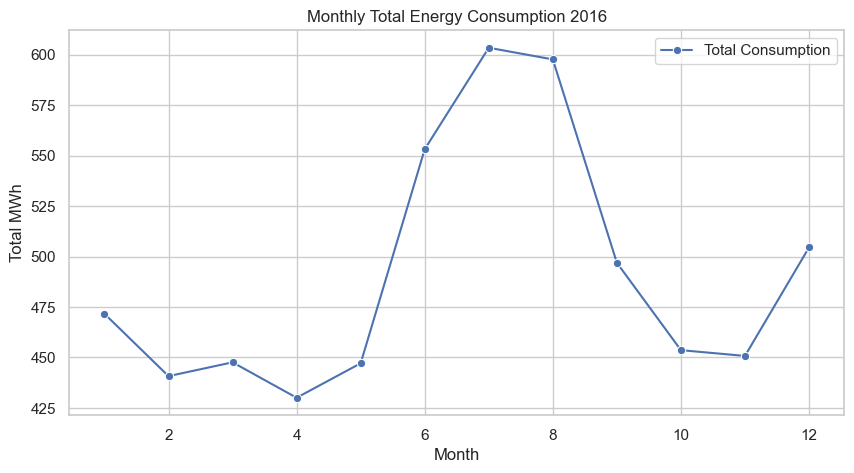

In [12]:
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_data, x='month', y='total_mwh', marker='o', label='Total Consumption')
plt.title('Monthly Total Energy Consumption 2016')
plt.xlabel('Month')
plt.ylabel('Total MWh')
plt.grid(True)
plt.legend()
plt.show()

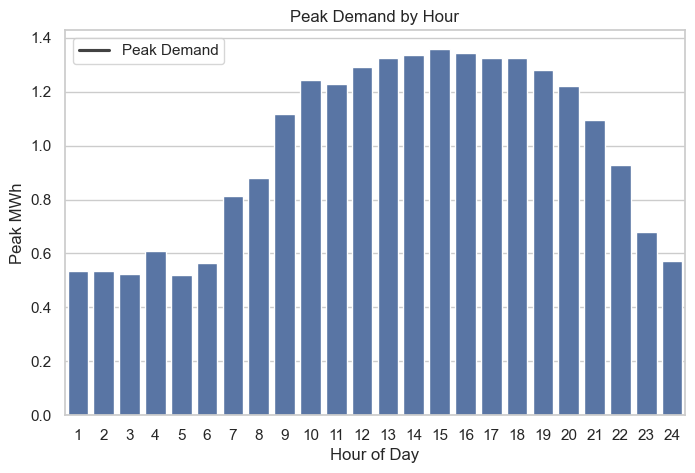

In [13]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=hourly_data, x='hour', y='peak_mwh')
ax.set_title('Peak Demand by Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Peak MWh')
plt.legend(['Peak Demand'])
plt.show()

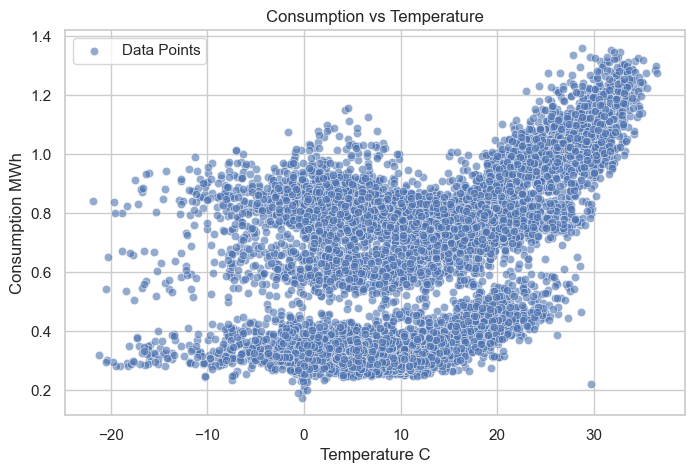

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='temperature', y='consumption', alpha=0.6, label='Data Points')
plt.title('Consumption vs Temperature')
plt.xlabel('Temperature C')
plt.ylabel('Consumption MWh')
plt.legend()
plt.show()